In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [3]:
# Data Preparation
# Read df
df = pd.read_csv("rv_30stocks_2index.csv")

# Rename
df = df.rename(columns={"Var1": "Date"})

# Convert to datetime
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Sort by date
df = df.sort_values("Date")

# Set as index
df = df.set_index("Date")

# Asset index reset
asset_df = pd.read_csv("stocks_30stocks_2index.csv", header=None)

asset_names = asset_df.iloc[:,0].tolist()
df.columns = asset_names
df.columns = df.columns.str.strip()
df.head()

,DJI,AAPL,ABT,AIG,AMGN,AXP,BA,BAC,C,CAT,...,MRK,MSFT,NKE,PG,SPY,UNH,UNP,VZ,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2000-07-05,0.000065,0.001242,0.000419,0.000219,0.000728,0.000406,0.000242,0.000328,0.000246,0.000764,...,0.000163,0.000324,0.000518,0.000153,0.000074,0.000301,0.000218,0.000322,0.000480,0.000258
2000-07-06,0.000054,0.001865,0.000224,0.000066,0.000660,0.000270,0.000225,0.000338,0.000362,0.000309,...,0.000136,0.000293,0.000334,0.000183,0.000100,0.000341,0.000256,0.001084,0.000601,0.000315
2000-07-07,0.000038,0.001319,0.000336,0.000120,0.000490,0.000403,0.000215,0.000398,0.000247,0.000280,...,0.000170,0.000318,0.000445,0.000539,0.000065,0.000374,0.000213,0.000411,0.000352,0.000132
2000-07-10,0.000034,0.002188,0.000369,0.000162,0.001440,0.000367,0.000419,0.000228,0.000220,0.000801,...,0.000078,0.000413,0.000271,0.000152,0.000067,0.000200,0.000147,0.000387,0.000359,0.000158
2000-07-11,0.000080,0.001691,0.000149,0.000103,0.000972,0.000556,0.000297,0.000256,0.000383,0.000539,...,0.000248,0.000446,0.000511,0.000156,0.000111,0.000170,0.000176,0.000238,0.000419,0.000207


In [4]:
df.to_csv("sample_data.csv", index=False)

# Regressors Definition

In [10]:
RV_d = df.copy()

In [11]:
RV_w = pd.DataFrame(index=df.index, columns=df.columns)

for col in df.columns:
    weekly_sum = 0
    # i from 0 to 4
    for i in range(5):
        weekly_sum += df[col].shift(i)
    RV_w[col] = weekly_sum / 5

In [12]:
RV_m = pd.DataFrame(index=df.index, columns=df.columns)

for col in df.columns:
    monthly_sum = 0
    for i in range(22):
        monthly_sum += df[col].shift(i)
    RV_m[col] = monthly_sum / 22

In [13]:
Target_1 = pd.DataFrame(index=df.index, columns=df.columns)

for col in df.columns:
    Target_1[col] = df[col].shift(-1)

In [14]:
Target_5 = pd.DataFrame(index=df.index, columns=df.columns)

for col in df.columns:
    future_sum = 0
    for i in range(1, 6):
        future_sum += df[col].shift(-i)
    Target_5[col] = future_sum / 5

In [15]:
Target_10 = pd.DataFrame(index=df.index, columns=df.columns)

for col in df.columns:
    future_sum = 0
    for i in range(1, 11):
        future_sum += df[col].shift(-i)
    Target_10[col] = future_sum / 10

In [16]:
Target_22 = pd.DataFrame(index=df.index, columns=df.columns)

for col in df.columns:
    future_sum = 0
    for i in range(1, 23):
        future_sum += df[col].shift(-i)
    Target_22[col] = future_sum / 22

In [17]:
for col in df.columns:

    df_single = pd.DataFrame({
        "RV": RV_d[col],
        "RV_w": RV_w[col],
        "RV_m": RV_m[col],
        "Target_1": Target_1[col],
        "Target_5": Target_5[col],
        "Target_10": Target_10[col],
        "Target_22": Target_22[col]
    })

    # choose horizon inside loop

In [18]:
df_single.head(22)

,RV,RV_w,RV_m,Target_1,Target_5,Target_10,Target_22
Date,,,,,,,
2000-07-05,0.000258,NaN,NaN,0.000315,0.000195,0.000170,0.000199
2000-07-06,0.000315,NaN,NaN,0.000132,0.000166,0.000160,0.000190
2000-07-07,0.000132,NaN,NaN,0.000158,0.000167,0.000163,0.000188
2000-07-10,0.000158,NaN,NaN,0.000207,0.000162,0.000171,0.000186
2000-07-11,0.000207,0.000214,NaN,0.000165,0.000145,0.000173,0.000181
2000-07-12,0.000165,0.000195,NaN,0.000166,0.000144,0.000177,0.000178
2000-07-13,0.000166,0.000166,NaN,0.000138,0.000154,0.000192,0.000177
2000-07-14,0.000138,0.000167,NaN,0.000134,0.000159,0.000196,0.000176
2000-07-17,0.000134,0.000162,NaN,0.000124,0.000180,0.000200,0.000174


In [19]:
df_model = df_single[["RV", "RV_w", "RV_m", "Target_5"]].dropna()

In [20]:
# User Input Panel
INITIAL_WINDOW = 1000    # number of observations before OOS starts
EXPANDING = True         # True = expanding window
ROLLING_WINDOW = 1000    # only used if EXPANDING=False

# Testing setup
#MAX_OOS = None # MaxOOS run for test
#df_single = df_single.iloc[:1500] # Slice df for test

In [21]:
# Select Target Panel
Target_dict = {
    1: Target_1,
    5: Target_5,
    10: Target_10,
    22: Target_22
}

horizon_targets = Target_dict

In [22]:
all_predictions = []

# LOOP OVER HORIZONS
for HORIZON, Target_panel in horizon_targets.items():

    for col in df.columns:

        df_single = pd.DataFrame({
            "RV": RV_d[col],
            "RV_w": RV_w[col],
            "RV_m": RV_m[col],
            "Target": Target_panel[col]
        }).dropna()

        n = len(df_single)

        #for t in range(INITIAL_WINDOW, min(n, INITIAL_WINDOW + MAX_OOS)):
        for t in range(INITIAL_WINDOW, n):
            
            # Leakage-Free Cutoff
            
            train_end = t - HORIZON

            if train_end <= 0:
                continue

            if EXPANDING:
                train = df_single.iloc[:train_end]
            else:
                train = df_single.iloc[
                    max(0, train_end - ROLLING_WINDOW):train_end
                ]

            if len(train) == 0:
                continue

            test = df_single.iloc[t]
            
            # Estimate HAR
            
            X_train = train[["RV", "RV_w", "RV_m"]]
            X_train = sm.add_constant(X_train)
            y_train = train["Target"]

            model = sm.OLS(y_train, X_train).fit()

            # Forecast at time t
            
            X_test = pd.DataFrame({
                "const": 1,
                "RV": test["RV"],
                "RV_w": test["RV_w"],
                "RV_m": test["RV_m"]
            }, index=[0])

            X_test = X_test[model.model.exog_names]

            forecast = model.predict(X_test).values[0]
            forecast = max(forecast, 1e-10)

            all_predictions.append({
                "Date": df_single.index[t],
                "Stock": col,
                "Horizon": HORIZON,
                "Forecast": forecast,
                "Actual": test["Target"]
            })

# Convert to DataFrame
predictions_df = pd.DataFrame(all_predictions)

In [24]:
print(predictions_df.shape)

(662336, 5)


In [25]:
print(predictions_df.groupby("Horizon").size())

Horizon
1     165856
5     165728
10    165568
22    165184
dtype: int64


In [26]:
check = predictions_df[
    (predictions_df["Stock"] == "AAPL") &
    (predictions_df["Horizon"] == 5)
].tail(10)

print(check)

             Date Stock  Horizon  Forecast    Actual
176204 2025-07-10  AAPL        5  0.000183  0.000096
176205 2025-07-11  AAPL        5  0.000155  0.000096
176206 2025-07-14  AAPL        5  0.000148  0.000101
176207 2025-07-15  AAPL        5  0.000156  0.000097
176208 2025-07-16  AAPL        5  0.000163  0.000080
176209 2025-07-17  AAPL        5  0.000137  0.000095
176210 2025-07-18  AAPL        5  0.000137  0.000091
176211 2025-07-21  AAPL        5  0.000150  0.000075
176212 2025-07-22  AAPL        5  0.000148  0.000075
176213 2025-07-23  AAPL        5  0.000134  0.000081


In [27]:
predictions_df.to_csv("HAR_predictions_full.csv", index=False)

# Evaluation Metrices

In [28]:
# Ensure positivity for QLIKE
predictions_df["Forecast_Pos"] = predictions_df["Forecast"].clip(lower=1e-10)

# etric Definitions 
predictions_df["MSE"] = (predictions_df["Forecast"] - predictions_df["Actual"])**2
predictions_df["MAE"] = (predictions_df["Forecast"] - predictions_df["Actual"]).abs()

predictions_df["Actual_Pos"] = predictions_df["Actual"].clip(lower=1e-10)

predictions_df["QLIKE"] = (
    predictions_df["Actual_Pos"] / predictions_df["Forecast_Pos"]
    - np.log(predictions_df["Actual_Pos"] / predictions_df["Forecast_Pos"])
    - 1
)

# Optional future metric placeholder:
# predictions_df["MAPE"] = ...

metric_list = ["MSE", "MAE", "QLIKE"]

eval_stock = (
    predictions_df
    .groupby(["Horizon", "Stock"])[metric_list]
    .mean()
    .reset_index()
)

In [29]:
# Cross-sectional Median construction
indices = ["DJI", "SPY"]

stocks_only = [
    s for s in predictions_df["Stock"].unique()
    if s not in indices
]

eval_median = (
    eval_stock
    .query("Stock in @stocks_only")
    .groupby("Horizon")[metric_list]
    .median()
    .reset_index()
)

eval_median["Stock"] = "Median_30"

In [30]:
eval_panel = pd.concat([eval_stock, eval_median], ignore_index=True)

eval_panel = eval_panel.sort_values(["Horizon", "Stock"])

eval_panel

,Horizon,Stock,MSE,MAE,QLIKE
0,1,AAPL,1.344616e-07,0.000145,0.205445
1,1,ABT,4.099057e-08,0.000072,0.166999
2,1,AIG,1.315913e-06,0.000294,0.188158
3,1,AMGN,6.577984e-08,0.000106,0.179599
4,1,AXP,1.971051e-07,0.000136,0.181455
...,...,...,...,...,...
123,22,UNH,7.618968e-08,0.000113,0.130475
124,22,UNP,7.280237e-08,0.000099,0.132107
125,22,VZ,3.138716e-08,0.000071,0.145284
126,22,WMT,2.128618e-08,0.000062,0.146214


In [31]:
eval_panel.to_csv("HAR_evaluation_panel.csv", index=False)

In [32]:
# keep only Median_30 + 2 indices
keep_entities = ["Median_30", "DJI", "SPY"]

eval_simple = (
    eval_panel
    .query("Stock in @keep_entities")
    .sort_values(["Horizon", "Stock"])
    .reset_index(drop=True)
)

eval_simple


,Horizon,Stock,MSE,MAE,QLIKE
0,1,DJI,2.718124e-08,0.000052,0.225947
1,1,Median_30,8.001269e-08,0.000098,0.167265
2,1,SPY,2.663873e-08,0.000046,0.225168
3,5,DJI,2.027275e-08,0.000048,0.190014
4,5,Median_30,5.931267e-08,0.000089,0.130830
5,5,SPY,1.752908e-08,0.000045,0.210722
6,10,DJI,2.039173e-08,0.000052,0.213621
7,10,Median_30,6.320445e-08,0.000092,0.127925
8,10,SPY,1.771898e-08,0.000049,0.241448
9,22,DJI,2.201726e-08,0.000059,0.273064


In [33]:
print(eval_panel.groupby("Horizon").size())

Horizon
1     33
5     33
10    33
22    33
dtype: int64


In [34]:
print(
    eval_panel[eval_panel["Stock"]=="Median_30"]
    .sort_values("Horizon")
)

     Horizon      Stock           MSE       MAE     QLIKE
128        1  Median_30  8.001269e-08  0.000098  0.167265
129        5  Median_30  5.931267e-08  0.000089  0.130830
130       10  Median_30  6.320445e-08  0.000092  0.127925
131       22  Median_30  6.461940e-08  0.000099  0.164048


In [35]:
with pd.ExcelWriter("HAR_results.xlsx") as writer:
    predictions_df.to_excel(writer, sheet_name="Predictions", index=False)
    eval_panel.to_excel(writer, sheet_name="Evaluation", index=False)

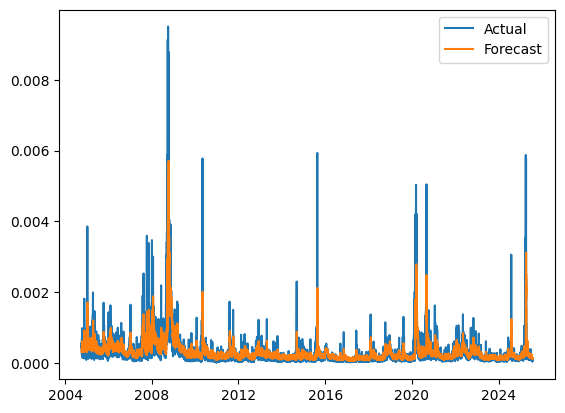

In [37]:
# Visualisation for Apple

aapl = predictions_df[predictions_df["Stock"]=="AAPL"]

plt.plot(aapl["Date"], aapl["Actual"], label="Actual")
plt.plot(aapl["Date"], aapl["Forecast"], label="Forecast")
plt.legend()
plt.show()